# Plotting posterior samples in various spaces

Initial analysis, sanity checks

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
posteriors = pd.read_csv("eps_samples_stack.csv", header=None, names = range(4090))
eps_raw = posteriors.to_numpy()

eps_mask = ~np.isnan(eps_raw)
sample_count_per_row = eps_mask.sum(axis=1)

bws = np.nanstd(eps_raw, axis=1) / sample_count_per_row**(1.0/5.0)

eps_samples_stack = np.nan_to_num(eps_raw,nan=0.0)

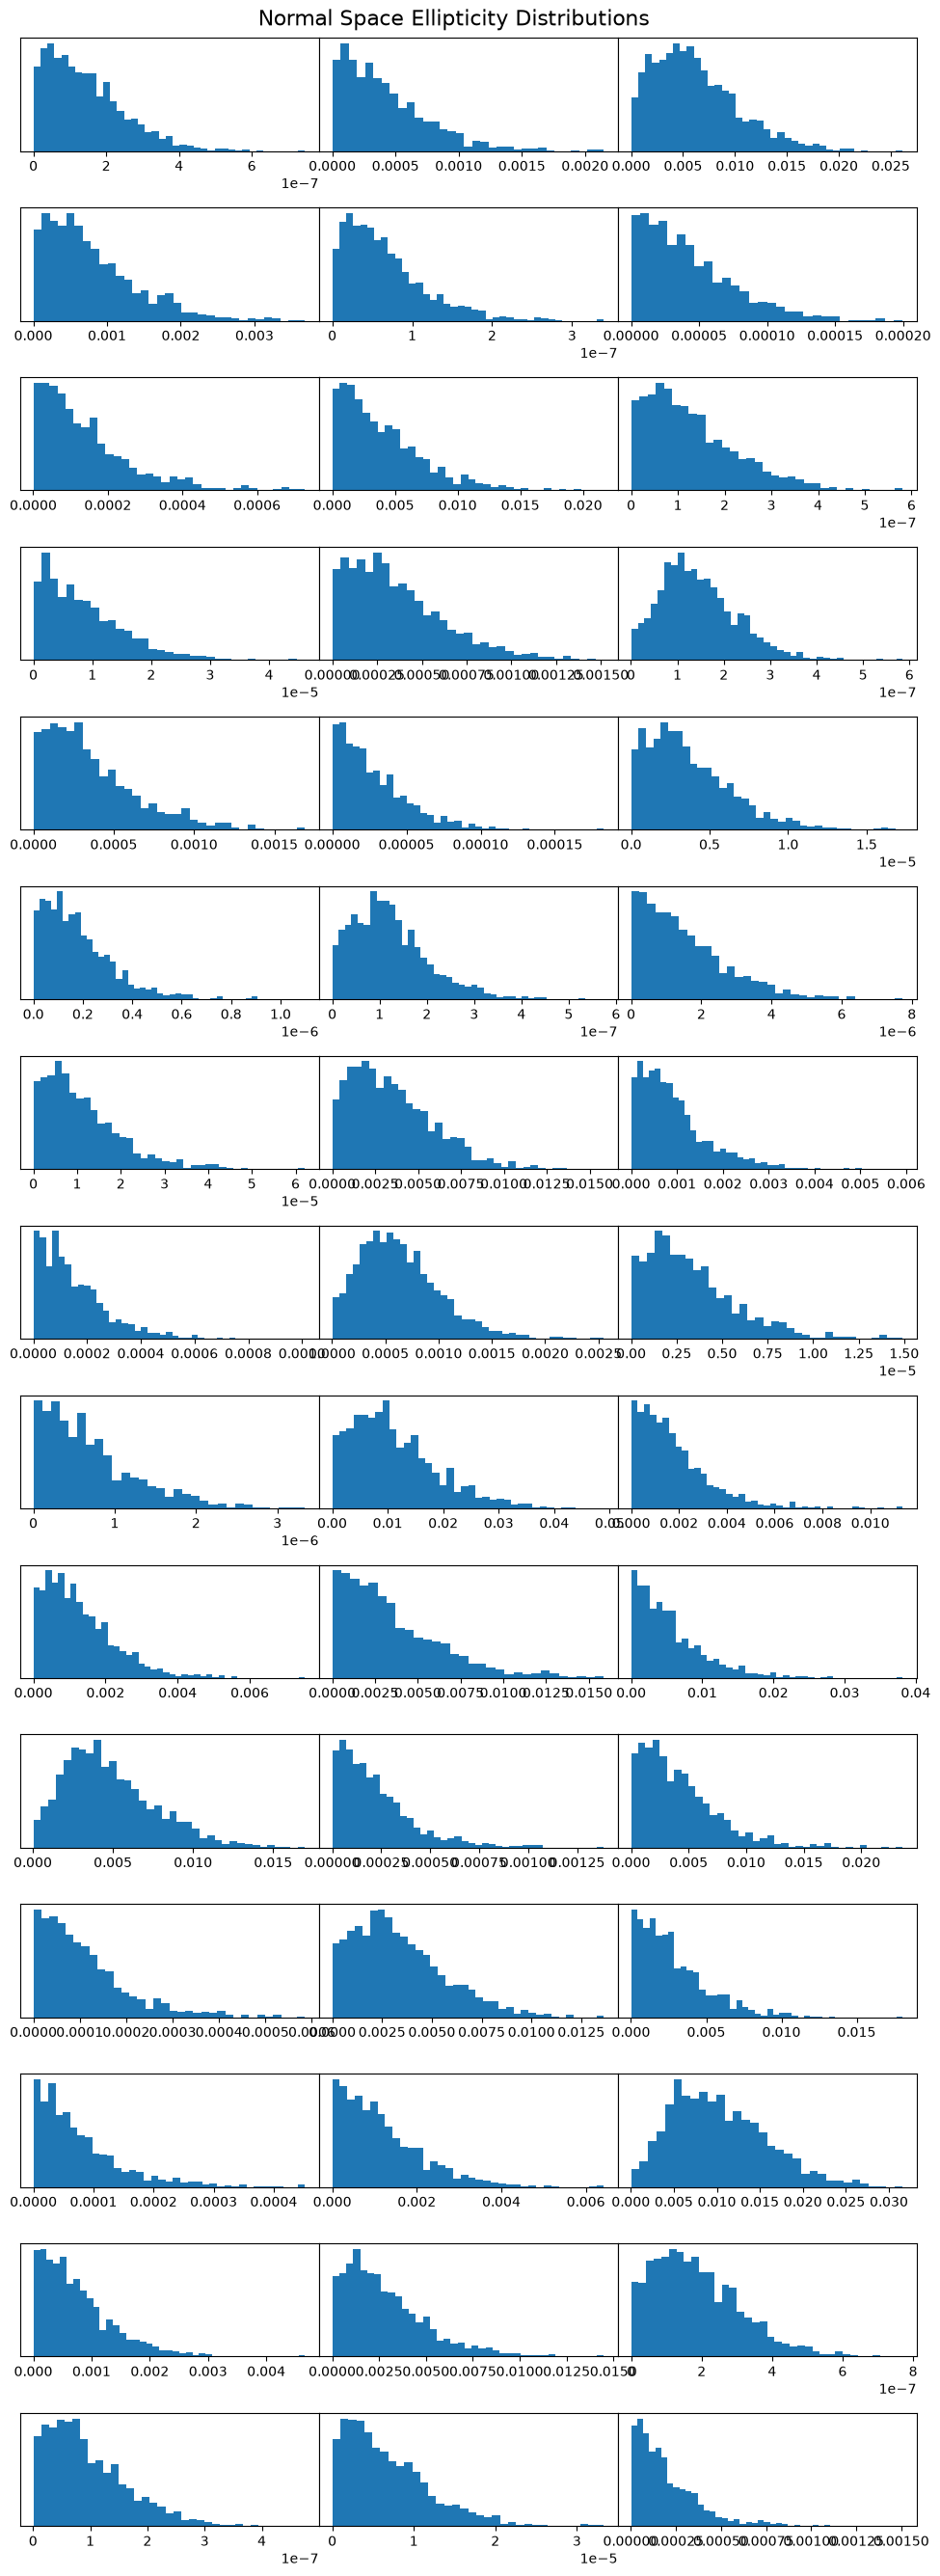

In [3]:
nrows = 15
ncols = 3
fig, axs = plt.subplots(nrows=nrows, ncols = ncols, figsize=(12,30))
plt.subplots_adjust(top=.97, wspace=0,hspace=0.5)

max = np.max(eps_samples_stack)

#bins = np.geomspace(min,max,num=20)
log_bins = np.logspace(np.log10(1e-13), np.log10(1e-5), 50)
bins = np.linspace(1e-13, 1e-9, 50)

min = np.min(eps_samples_stack[eps_samples_stack > 0])

i = 0

plt.suptitle("Normal Space Ellipticity Distributions", fontsize = 16)

for row in range(nrows):
    for col in range (ncols):
        ax = axs[row,col]
        arr = eps_samples_stack[i]
        ax.hist(arr[arr>0], bins='auto')

        #ax.set_xscale('log')


        #ax.set_xlim(1e-14,None)
        ax.get_yaxis().set_visible(False)
        #if row<nrows-1:
        #    ax.get_xaxis().set_visible(False)

        i+=1

In [ ]:
nrows = 15
ncols = 3
fig, axs = plt.subplots(nrows=nrows, ncols = ncols, figsize=(12,30))
plt.subplots_adjust(top=.97, wspace=0,hspace=0.35)

max = np.max(eps_samples_stack)

#bins = np.geomspace(min,max,num=20)
log_bins = np.logspace(np.log10(1e-13), np.log10(1e-5), 50)
bins = np.linspace(1e-13, 1e-9, 50)

min = np.min(eps_samples_stack[eps_samples_stack > 0])

i = 0

plt.suptitle("Log Space Ellipticity Distributions", fontsize = 16)

for row in range(nrows):
    for col in range (ncols):
        ax = axs[row,col]
        arr = eps_samples_stack[i]
        ax.hist(arr[arr>0], bins=log_bins)

        ax.set_xscale('log')


        #ax.set_xlim(1e-14,None)
        ax.get_yaxis().set_visible(False)
        #if row<nrows-1:
        #    ax.get_xaxis().set_visible(False)

        i+=1